# 01 — EDA: HR Attrition

Analiza eksploracyjna danych `data/raw/HR.csv`. Cel: przewidzieć **Attrition** (rezygnacja pracownika, 0/1).

> Feature engineering v3: **36 cech inżynierowanych** (19 v1/v2 + 17 v3). Łącznie po OHE: **66 kolumn wejściowych**.

> Importuje biblioteki (`pandas`, `matplotlib`), ładuje i czyści dane HR, wyświetla pierwsze wiersze zbioru.

In [ ]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))

from data_loader import load_hr
from features import clean_data

df = clean_data(load_hr())
print(f'Zaladowano {len(df):,} wierszy, {df.shape[1]} kolumn')
df.head()

Zaladowano 1,470 wierszy, 35 kolumn


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,...,80,0,8,0,1,6,4,0,5,1
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,...,80,1,10,3,3,10,7,1,7,0
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,...,80,0,7,3,3,0,0,0,0,1
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,...,80,0,8,3,3,8,7,3,0,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,...,80,1,6,3,3,2,2,2,2,0


> Ustawia rozdzielczość wykresów matplotlib i tworzy katalog `reports/` na pliki wynikowe.

In [2]:
import matplotlib.pyplot as plt

(ROOT / 'reports').mkdir(parents=True, exist_ok=True)
plt.rcParams['figure.dpi'] = 100


## 1. Podstawowe informacje

> Wyświetla liczbę wierszy, typy kolumn oraz statystyki opisowe (`describe`) dla cech numerycznych i kategorycznych.

In [3]:
print('Wiersze:', len(df), '| Kolumny:', df.shape[1])
print('Braki danych:', int(df.isnull().sum().sum()))
print('\nTypy:')
display(df.dtypes.value_counts())

display(df.describe().T)
display(df.select_dtypes(include='object').describe().T)

Wiersze: 1470 | Kolumny: 35
Braki danych: 0

Typy:


int64    28
str       7
Name: count, dtype: int64

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


C:\Users\joann\AppData\Local\Temp\ipykernel_13128\3262884763.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.select_dtypes(include='object').describe().T)


,count,unique,top,freq
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470


## 2. Zmienna docelowa — Attrition

> Liczy liczebność klas Attrition (0=zostaje, 1=odchodzi), oblicza odsetek rezygnacji i rysuje wykres słupkowy rozkładu.

Attrition
0    1233
1     237
Name: count, dtype: int64
Udzial rezygnacji: 16.1%


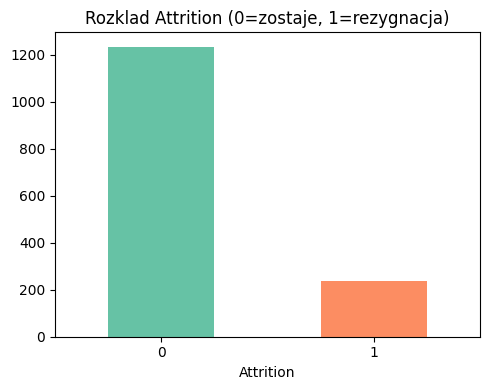

In [4]:
counts = df['Attrition'].value_counts().sort_index()
print(counts)
print(f"Udzial rezygnacji: {counts.get(1, 0) / len(df):.1%}")

fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind='bar', ax=ax, color=['#66c2a5', '#fc8d62'], rot=0)
ax.set_title('Rozklad Attrition (0=zostaje, 1=rezygnacja)')
ax.set_xlabel('Attrition')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'eda_attrition_distribution.png', dpi=100)
plt.show()

## 3. Cechy kategoryczne vs Attrition

> Rysuje wykresy słupkowe P(Attrition=1) dla kluczowych cech kategorycznych: OverTime, Department, JobRole, MaritalStatus, BusinessTravel.

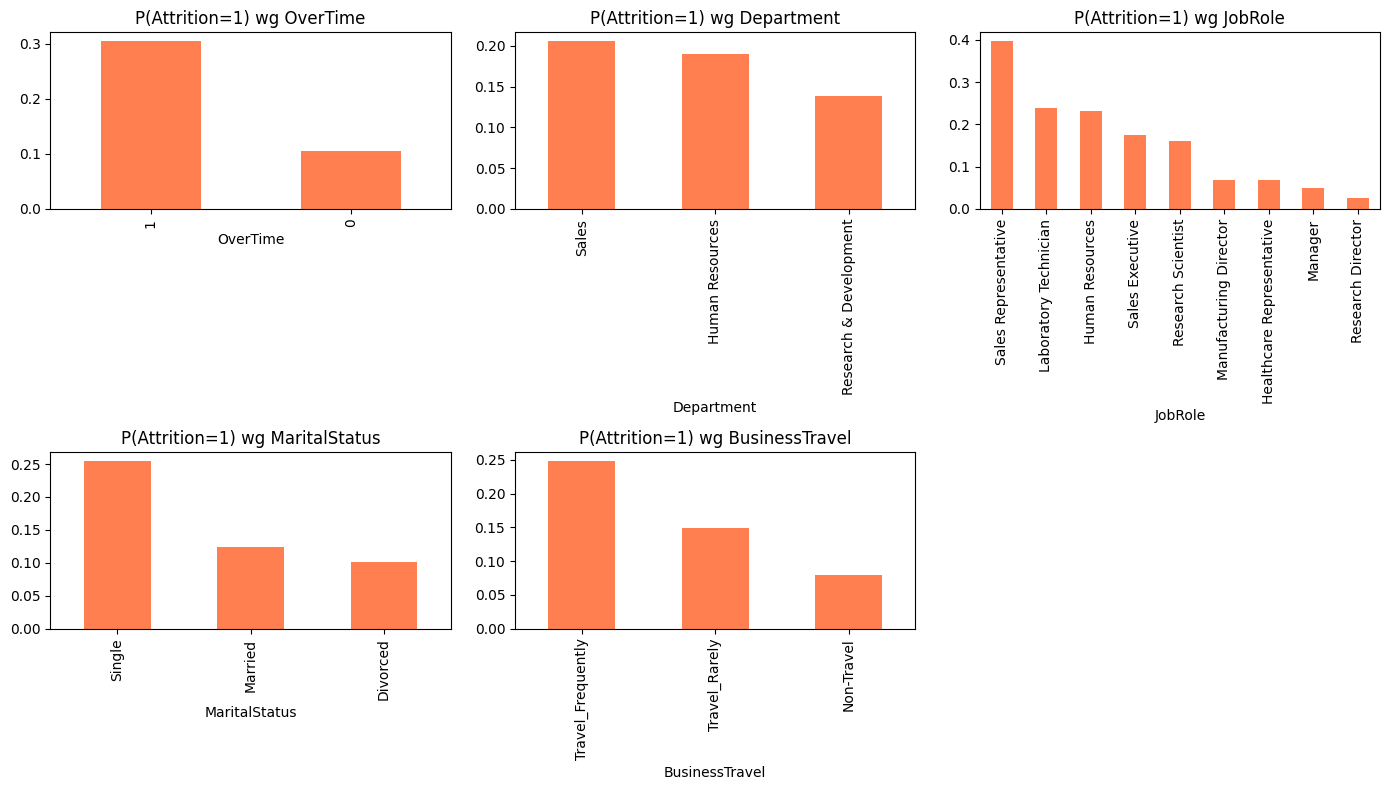

In [5]:
cat_cols = ['OverTime', 'Department', 'JobRole', 'MaritalStatus', 'BusinessTravel']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for i, col in enumerate(cat_cols):
    pd.crosstab(df[col], df['Attrition'], normalize='index')[1].sort_values(ascending=False).plot(
        kind='bar', ax=axes[i], color='coral', title=f'P(Attrition=1) wg {col}'
    )
axes[-1].axis('off')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'eda_categorical_attrition.png', dpi=100)
plt.show()

## 4. Cechy numeryczne

> Oblicza macierz korelacji Pearsona dla cech numerycznych i rysuje jej heatmapę.

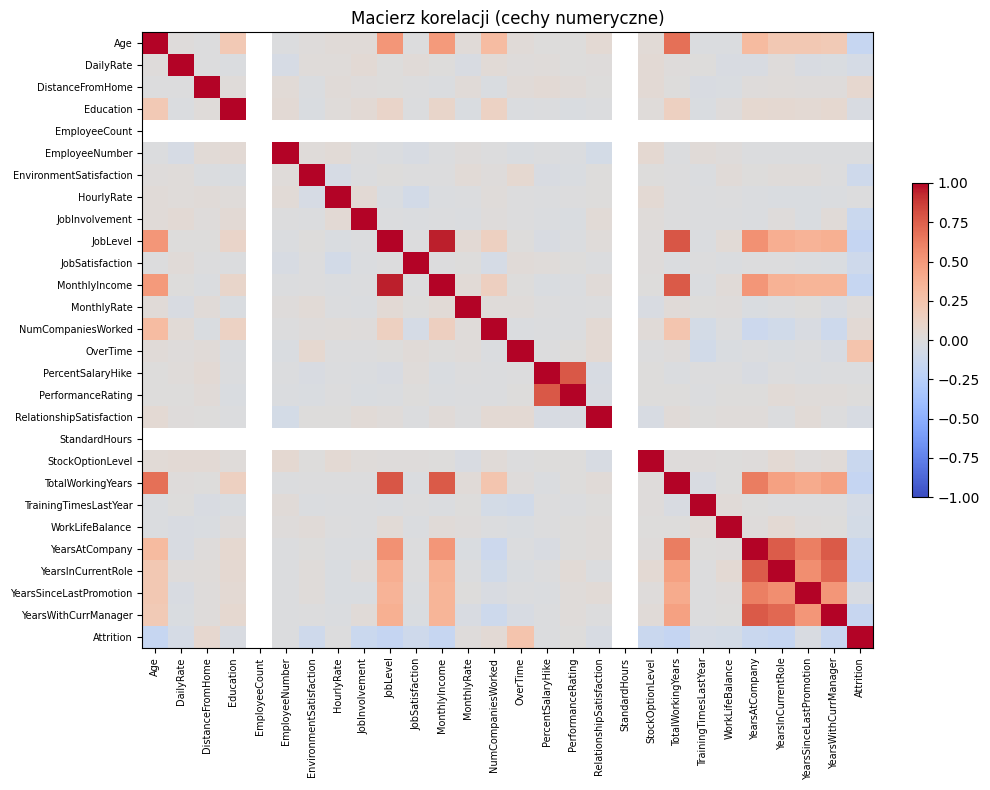

In [6]:
num_cols = df.select_dtypes(include='number').columns #.drop('Attrition', errors='ignore')
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr.columns, fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.02)
ax.set_title('Macierz korelacji (cechy numeryczne)')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'eda_correlation_heatmap.png', dpi=100)
plt.show()

> Rysuje nakładające się histogramy 6 kluczowych cech numerycznych z podziałem na Attrition=0 i Attrition=1 — pokazuje różnice w rozkładach.

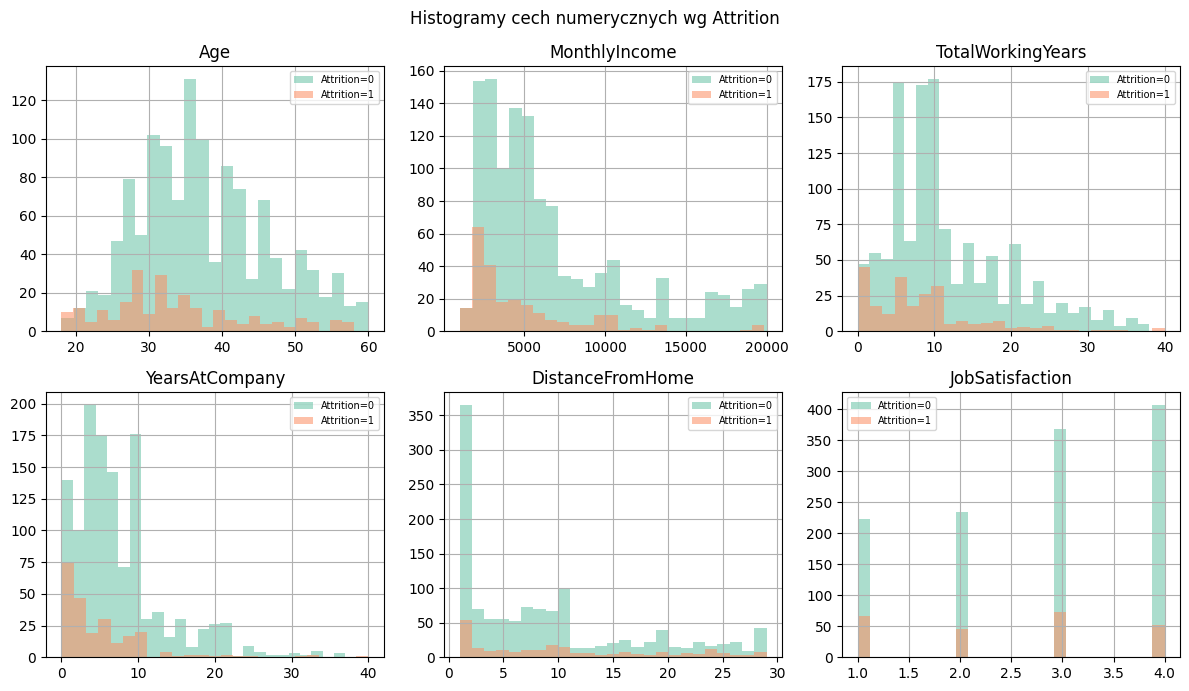

In [7]:
key_hist = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'DistanceFromHome', 'JobSatisfaction']
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()
for ax, col in zip(axes, key_hist):
    df[df['Attrition'] == 0][col].hist(ax=ax, bins=25, alpha=0.55, label='Attrition=0', color='#66c2a5')
    df[df['Attrition'] == 1][col].hist(ax=ax, bins=25, alpha=0.55, label='Attrition=1', color='#fc8d62')
    ax.set_title(col)
    ax.legend(fontsize=7)
fig.suptitle('Histogramy cech numerycznych wg Attrition')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'eda_histograms.png', dpi=100)
plt.show()


> Rysuje boxploty 5 kluczowych cech numerycznych (Wiek, Dochód, Staż itp.) w podziale na Attrition — porównuje mediany i rozrzut między klasami.

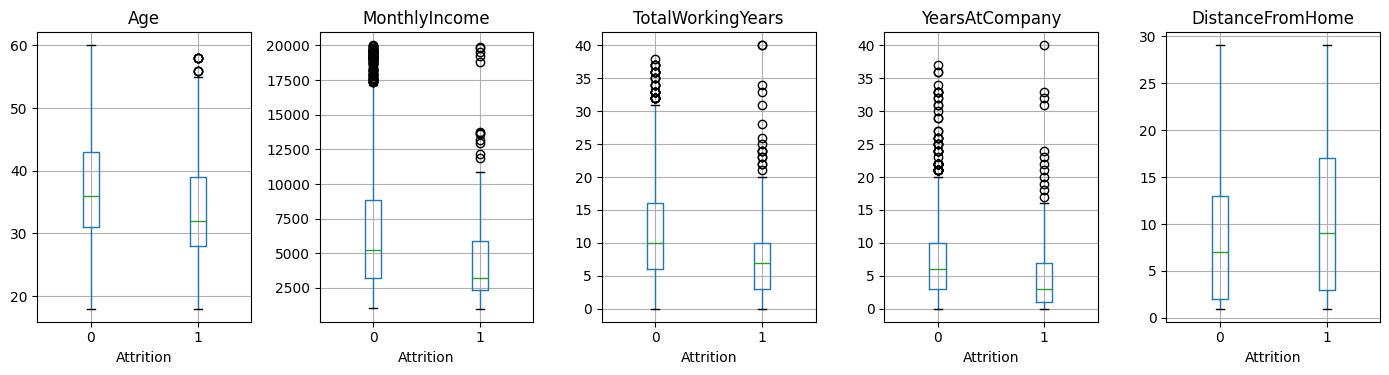

In [8]:
key_num = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'DistanceFromHome']
fig, axes = plt.subplots(1, len(key_num), figsize=(14, 4))
for ax, col in zip(axes, key_num):
    df.boxplot(column=col, by='Attrition', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Attrition')
fig.suptitle('')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'eda_numeric_boxplots.png', dpi=100)
plt.show()

### Wnioski EDA
- Klasa **Attrition=1** jest niezbalansowana (~16% rezygnacji).
- **OverTime=Yes** silnie związany z odejściem.
- Niższe **JobSatisfaction**, **WorkLifeBalance** i krótszy staż u obecnego managera często współwystępują z attrition.
- Cechy v3 (**BurnoutRiskScore**, **StabilityComposite**, **TravelFatigue**) wzmacniają te sygnały jako kompozytowe wskaźniki ryzyka.

## 5. Feature Engineering v3 — nowe cechy vs Attrition

Generuje cechy v3 za pomocą `engineer_features()` i porównuje ich średnie wartości dla Attrition=0 i Attrition=1 w jednej tabeli.

In [9]:
from features import engineer_features

eng = engineer_features(df)

v3_cols = [
    'IncomePerYearAtCompany', 'OvertimeAndLowSatisfaction', 'YoungAndOvertime',
    'IncomeVsJobLevel', 'SatisfactionVariance', 'TotalExperienceGap',
    'ManagerInstability', 'FrequentJobSwitcher', 'BurnoutRiskScore',
    'IncomePerDependent', 'LateCareerNoPromotion', 'CommuteRisk',
    'ExperienceMismatch', 'StabilityComposite', 'TravelFatigue',
    'LowIncomeHighTenure', 'CareerGrowthIndex',
]

print(f'Dostępne cechy v3: {len(v3_cols)}')
eng[v3_cols + ['Attrition']].groupby('Attrition').mean().T.round(3)

Dostępne cechy v3: 17


Attrition,0,1
IncomePerYearAtCompany,1171.419,1160.359
OvertimeAndLowSatisfaction,0.079,0.236
YoungAndOvertime,0.036,0.211
IncomeVsJobLevel,1971.127,1645.906
SatisfactionVariance,0.933,1.017
TotalExperienceGap,4.494,3.114
ManagerInstability,3.002,2.278
FrequentJobSwitcher,0.195,0.283
BurnoutRiskScore,2.909,3.945
IncomePerDependent,2670.655,1757.458


Rysuje boxploty 9 wybranych cech v3 z podziałem na klasy Attrition — wizualne porównanie rozkładów nowych wskaźników ryzyka.

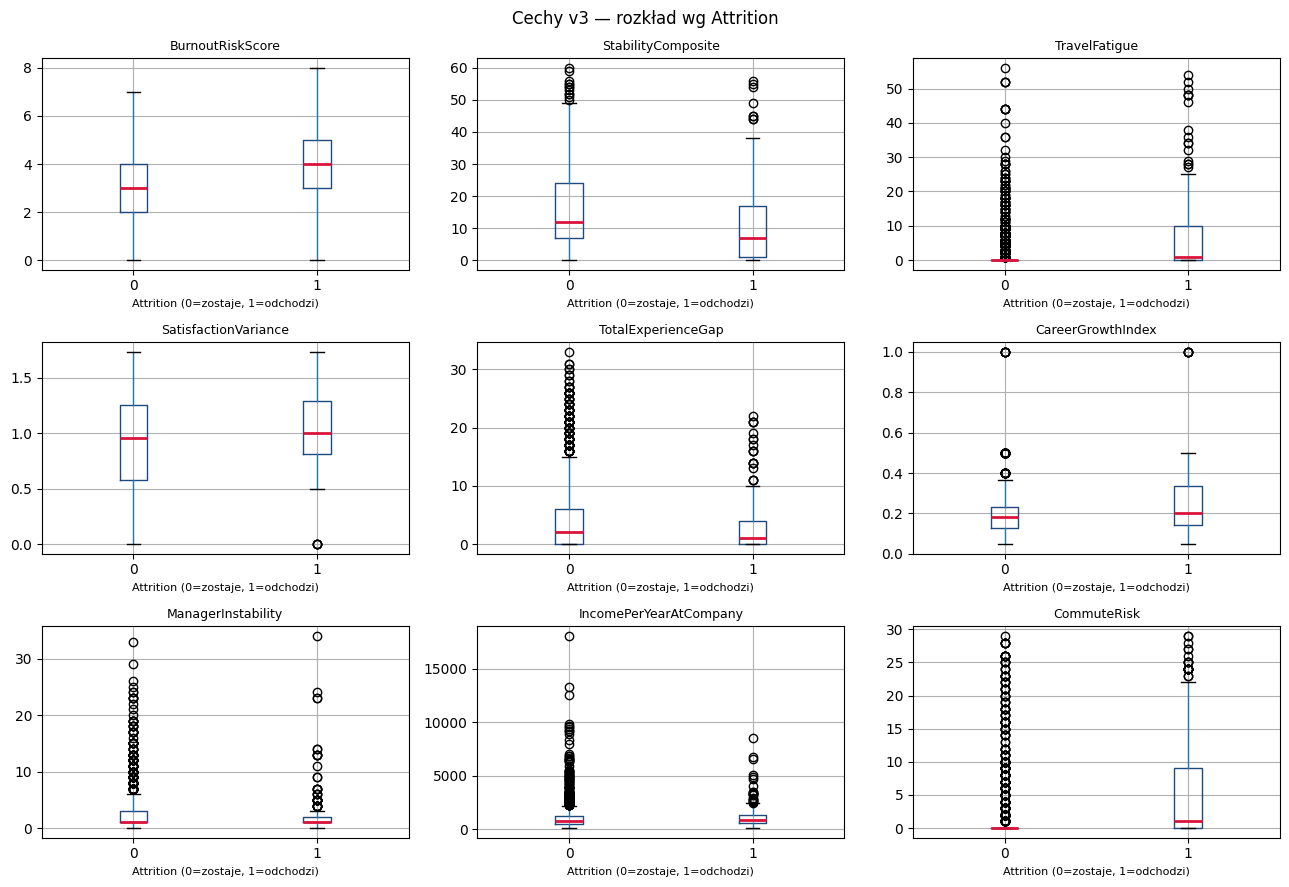

In [10]:
# Boxploty wybranych cech v3 wg Attrition
import matplotlib.pyplot as plt

plot_cols = [
    'BurnoutRiskScore', 'StabilityComposite', 'TravelFatigue',
    'SatisfactionVariance', 'TotalExperienceGap', 'CareerGrowthIndex',
    'ManagerInstability', 'IncomePerYearAtCompany', 'CommuteRisk',
]

fig, axes = plt.subplots(3, 3, figsize=(13, 9))
axes = axes.ravel()
for ax, col in zip(axes, plot_cols):
    eng.boxplot(column=col, by='Attrition', ax=ax, 
                boxprops=dict(color='#1F497D'),
                medianprops=dict(color='crimson', lw=2))
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('Attrition (0=zostaje, 1=odchodzi)', fontsize=8)
fig.suptitle('Cechy v3 — rozkład wg Attrition', fontsize=12)
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'eda_v3_features_boxplots.png', dpi=100)
plt.show()

> Oblicza odsetek odejść P(Attrition=1) dla binarnych flag v3 — porównuje ryzyko przy wartości flagi 0 i 1.

In [11]:
# Cechy binarne v3 — wskaźnik Attrition=1
binary_v3 = [
    'OvertimeAndLowSatisfaction', 'YoungAndOvertime',
    'FrequentJobSwitcher', 'LateCareerNoPromotion',
]


rates = {}
for col in binary_v3:
    g = eng.groupby(col)['Attrition'].mean()
    rates[col] = {'flaga=0': round(g.get(0, 0), 3), 'flaga=1': round(g.get(1, 0), 3)}

print('P(Attrition=1) dla cech binarnych v3:')
display(pd.DataFrame(rates).T)

P(Attrition=1) dla cech binarnych v3:


,flaga=0,flaga=1
OvertimeAndLowSatisfaction,0.137,0.366
YoungAndOvertime,0.136,0.532
FrequentJobSwitcher,0.146,0.218
LateCareerNoPromotion,0.162,0.152
